In [13]:
import os
import sys
parent_dir = os.path.abspath('..')
sys.path.append(parent_dir) #set root to path so src visible

# Import des librairies
!pip install catboost xgboost lightgbm catboost scikit-learn matplotlib pandas
import numpy as np
import matplotlib.pyplot as plt 

## Data loading
import s3fs
import time
import pandas as pd
import logging
logging.basicConfig(level=logging.INFO)  #to be able to see the logging info+warnings(to only see warnings: logging.DEBUG)

## Data preprocessing
from src.data_processing.data_load import data_loading
from src.data_processing.data_processing import DataProcessor

In [3]:
df_portefeuille = data_loading("training")

In [4]:
# On accède au premier objet du tuple, puis aux colonnes
print(df_portefeuille[0].columns.tolist())

['client_code', 'client_age_souscripteur', 'client_sexe_souscripteur', 'client_ro_souscripteur', 'client_code_postal', 'client_departement', 'client_departement_avant_changement_12_mois', 'client_a_conjoint', 'client_nb_enfants', 'client_structure_familiale', 'client_nb_assures_contrat', 'client_a_garantie_prevoyance', 'client_produit', 'client_garantie_base', 'client_garantie_base_plus_options', 'client_millesime_tarifaire_produit', 'client_zone_tarifaire', 'client_type_zone_tarifaire', 'client_est_contrat_madelin', 'client_date_debut_effet_garantie', 'client_anciennete_contrat_annees', 'client_cotisations_annualisees_n_moins2', 'client_cotisations_annualisees_n_moins1', 'client_cotisations_annualisees_n', 'client_cotisations_annualisees_n_plus1', 'client_mode_paiement', 'client_frequence_paiement', 'client_nom_banque', 'client_nps_date_reponse_n', 'client_nps_note_reco_n', 'client_nps_verbatim_n', 'client_nps_date_reponse_n_moins1', 'client_nps_note_reco_n_moins1', 'client_nps_verbat

In [5]:
df = df_portefeuille[0]
# Liste des colonnes cibles
colonnes_nps = [
    'client_nps_date_reponse_n', 
    'client_nps_note_reco_n', 
    'client_nps_verbatim_n', 
    'client_nps_date_reponse_n_moins1', 
    'client_nps_note_reco_n_moins1', 
    'client_nps_verbatim_n_moins1',
    'target_resiliation_6mois'

]

# Extraction dans un nouveau DataFrame
df_nps = df[colonnes_nps]

# Afficher les premières lignes pour vérifier
print(df_nps.head())

  client_nps_date_reponse_n  client_nps_note_reco_n client_nps_verbatim_n  \
0                       NaN                     NaN                   NaN   
1                       NaN                     NaN                   NaN   
2                       NaN                     NaN                   NaN   
3                       NaN                     NaN                   NaN   
4                       NaN                     NaN                   NaN   

  client_nps_date_reponse_n_moins1  client_nps_note_reco_n_moins1  \
0                              NaN                            NaN   
1                              NaN                            NaN   
2                              NaN                            NaN   
3                              NaN                            NaN   
4                              NaN                            NaN   

  client_nps_verbatim_n_moins1  target_resiliation_6mois  
0                          NaN                         0  
1   

In [6]:
df_nps.isna().sum()

client_nps_date_reponse_n           125100
client_nps_note_reco_n              125100
client_nps_verbatim_n               126629
client_nps_date_reponse_n_moins1    127060
client_nps_note_reco_n_moins1       127060
client_nps_verbatim_n_moins1        128204
target_resiliation_6mois                 0
dtype: int64

In [7]:
!pip install pandas wordcloud matplotlib textblob transformers torch vaderSentiment-fr

INFO:httpx:HTTP Request: HEAD https://huggingface.co/nlptown/bert-base-multilingual-uncased-sentiment/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/nlptown/bert-base-multilingual-uncased-sentiment/8f6f4e3a8f70be4b65d3a4a8762b6d781cda240d/config.json "HTTP/1.1 200 OK"
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 6730.01it/s]
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/nlptown/bert-base-multilingual-uncased-sentiment/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/nlptown/bert-base-multilingual-uncased-sentiment/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/nlptown/bert-base-multilingual-uncased-sentiment "HTTP/1.1 200 OK"


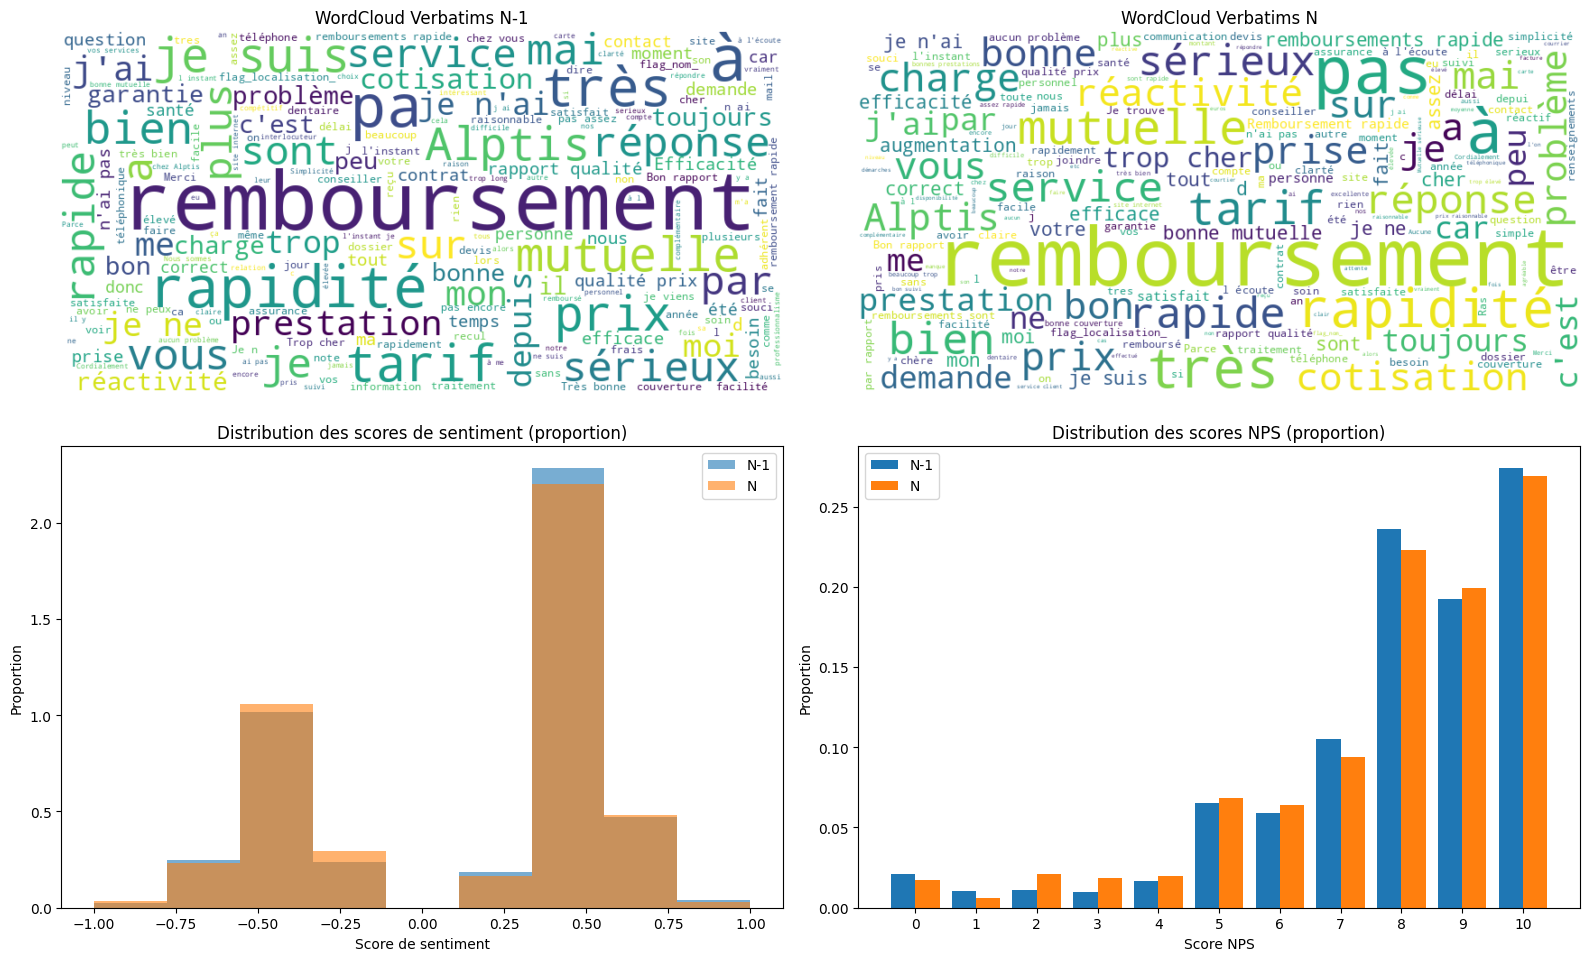

Note moyenne N-1 : 7.90
Note moyenne N   : 7.83

Répartition sentiments N-1 :
sentiment_label_n1
Positif    763
Neutre       0
Négatif    390
Name: count, dtype: int64

Répartition sentiments N :
sentiment_label_n
Positif    737
Neutre       0
Négatif    416
Name: count, dtype: int64


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from textblob import TextBlob
from vaderSentiment_fr.vaderSentiment import SentimentIntensityAnalyzer
from transformers import pipeline



df_nps = df.dropna(subset=['client_nps_verbatim_n', 'client_nps_verbatim_n_moins1']).copy()

sentiment_model = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment"
)

def sentiment_transformer(text):
    result = sentiment_model(str(text))[0]
    return result["score"] if result["label"] in ["4 stars", "5 stars"] else -result["score"]


def sentiment_label(score):
    if score > 0.1:
        return "Positif"
    elif score < -0.1:
        return "Négatif"
    else:
        return "Neutre"

df_nps["sentiment_score_n"] = df_nps["client_nps_verbatim_n"].apply(sentiment_transformer)
df_nps["sentiment_score_n1"] = df_nps["client_nps_verbatim_n_moins1"].apply(sentiment_transformer)

df_nps["sentiment_label_n"] = df_nps["sentiment_score_n"].apply(sentiment_label)
df_nps["sentiment_label_n1"] = df_nps["sentiment_score_n1"].apply(sentiment_label)

texte_n = " ".join(df_nps["client_nps_verbatim_n"].astype(str))
texte_n1 = " ".join(df_nps["client_nps_verbatim_n_moins1"].astype(str))

stop_words = set([
    'le', 'la', 'les', 'de', 'des', 'du', 'un', 'une', 'et', 'en', 'dans',
    'pour', 'que', 'qui', 'au', 'aux', 'avec', 'ce', 'cette', 'ces', 'est'
])

wordcloud_n = WordCloud(
    width=800,
    height=400,
    background_color="white",
    stopwords=stop_words
).generate(texte_n)

wordcloud_n1 = WordCloud(
    width=800,
    height=400,
    background_color="white",
    stopwords=stop_words
).generate(texte_n1)

mean_n = df_nps["client_nps_note_reco_n"].mean()
mean_n1 = df_nps["client_nps_note_reco_n_moins1"].mean()

sent_n = df_nps["sentiment_label_n"].value_counts().reindex(["Positif", "Neutre", "Négatif"], fill_value=0)
sent_n1 = df_nps["sentiment_label_n1"].value_counts().reindex(["Positif", "Neutre", "Négatif"], fill_value=0)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].imshow(wordcloud_n1, interpolation="bilinear")
axes[0, 0].axis("off")
axes[0, 0].set_title("WordCloud Verbatims N-1")

axes[0, 1].imshow(wordcloud_n, interpolation="bilinear")
axes[0, 1].axis("off")
axes[0, 1].set_title("WordCloud Verbatims N")

bins = np.linspace(-1, 1, 10)

axes[1, 0].hist(
    df_nps["sentiment_score_n1"],
    bins=bins,
    alpha=0.6,
    label="N-1",
    density=True
)

axes[1, 0].hist(
    df_nps["sentiment_score_n"],
    bins=bins,
    alpha=0.6,
    label="N",
    density=True
)

axes[1, 0].set_title("Distribution des scores de sentiment (proportion)")
axes[1, 0].set_xlabel("Score de sentiment")
axes[1, 0].set_ylabel("Proportion")
axes[1, 0].legend()

bins = np.arange(0, 12) - 0.5

counts_n1, _ = np.histogram(df_nps["client_nps_note_reco_n_moins1"], bins=bins)
counts_n, _ = np.histogram(df_nps["client_nps_note_reco_n"], bins=bins)

prop_n1 = counts_n1 / counts_n1.sum()
prop_n = counts_n / counts_n.sum()

x = np.arange(0, 11)
axes[1, 1].bar(x - 0.2, prop_n1, width=0.4, label="N-1")
axes[1, 1].bar(x + 0.2, prop_n, width=0.4, label="N")
axes[1, 1].set_xticks(x)
axes[1, 1].set_title("Distribution des scores NPS (proportion)")
axes[1, 1].set_xlabel("Score NPS")
axes[1, 1].set_ylabel("Proportion")
axes[1, 1].legend()
plt.tight_layout()
plt.show()

print(f"Note moyenne N-1 : {mean_n1:.2f}")
print(f"Note moyenne N   : {mean_n:.2f}")

print("\nRépartition sentiments N-1 :")
print(sent_n1)

print("\nRépartition sentiments N :")
print(sent_n)

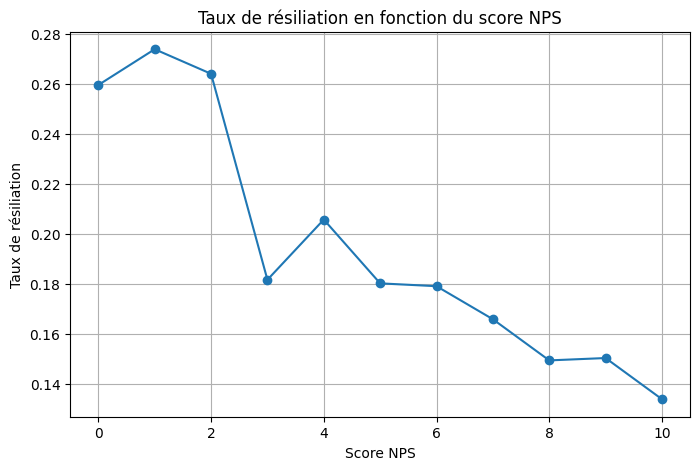

In [14]:
resiliation_by_nps = df_nps.groupby("client_nps_note_reco_n")["target_resiliation_6mois"].mean()

plt.figure(figsize=(8,5))
resiliation_by_nps.plot(marker="o")

plt.title("Taux de résiliation en fonction du score NPS")
plt.xlabel("Score NPS")
plt.ylabel("Taux de résiliation")
plt.grid()

plt.show()

In [18]:
# Liste de mots-clés liés au prix/tarif
mots_cles_prix = ['prix', 'tarif', 'cher', 'cotisation', 'augmentation', 'coût', 'cout']

# Création d'un flag (0 ou 1) pour les clients mentionnant le prix
pattern = '|'.join(mots_cles_prix)
df_nps['mention_prix'] = df_nps['client_nps_verbatim_n'].str.contains(pattern, case=False, na=False)

# On affine : on ne veut que ceux qui en parlent NÉGATIVEMENT (Sentiment < 0)
df_prix_negatif = df_nps[(df_nps['mention_prix'] == True) & (df_nps['sentiment_score_n'] < 0)]

In [19]:
target = 'target_resiliation_6mois'

taux_churn_prix = df_prix_negatif[target].mean() * 100
taux_churn_global = df_nps[target].mean() * 100

print(f"Nombre de clients mécontents du prix : {len(df_prix_negatif)}")
print(f"Taux de churn (Segment Prix) : {taux_churn_prix:.2f}%")
print(f"Taux de churn (Moyenne Globale) : {taux_churn_global:.2f}%")

# Calcul de l' "Over-risk" (Sur-risque)
sur_risque = taux_churn_prix / taux_churn_global
print(f"Ces clients sont {sur_risque:.1f} fois plus susceptibles de partir.")

Nombre de clients mécontents du prix : 24
Taux de churn (Segment Prix) : 29.17%
Taux de churn (Moyenne Globale) : 19.08%
Ces clients sont 1.5 fois plus susceptibles de partir.


/tmp/ipykernel_224128/4151564389.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Groupe', y='Taux de Churn (%)', data=data_plot, palette=['grey', 'red'])


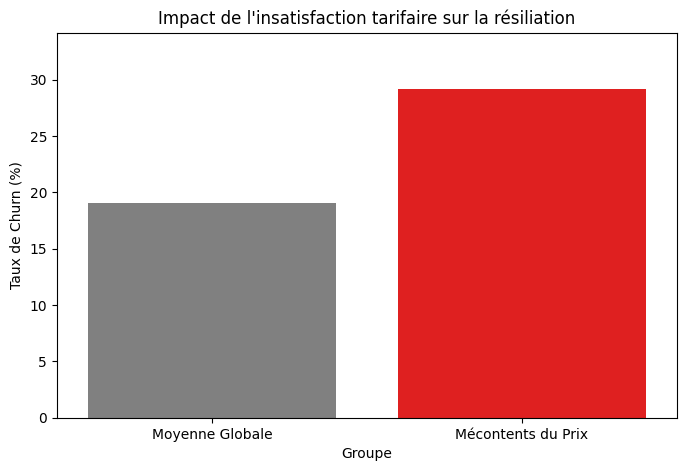

In [20]:
import seaborn as sns

data_plot = pd.DataFrame({
    'Groupe': ['Moyenne Globale', 'Mécontents du Prix'],
    'Taux de Churn (%)': [taux_churn_global, taux_churn_prix]
})

plt.figure(figsize=(8, 5))
sns.barplot(x='Groupe', y='Taux de Churn (%)', data=data_plot, palette=['grey', 'red'])
plt.title('Impact de l\'insatisfaction tarifaire sur la résiliation')
plt.ylim(0, max(taux_churn_prix, taux_churn_global) + 5)
plt.show()

In [26]:
# 1. Définition des segments NPS
def segment_nps(note):
    if note <= 6:
        return 'Détracteur'
    elif note <= 8:
        return 'Passif'
    else:
        return 'Promoteur'

df_nps['categorie_nps'] = df_nps['client_nps_note_reco_n'].apply(segment_nps)

# 2. Calcul du taux de churn par segment
target = 'target_resiliation_6mois'
stats_nps = df_nps.groupby('categorie_nps')[target].mean() * 100

# 3. Affichage des résultats
print("--- Taux de Churn par Segment NPS ---")
print(stats_nps.sort_values(ascending=False))

--- Taux de Churn par Segment NPS ---
categorie_nps
Détracteur    22.983871
Passif        20.547945
Promoteur     16.296296
Name: target_resiliation_6mois, dtype: float64


/tmp/ipykernel_224128/1056201347.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=stats_nps.index, y=stats_nps.values, palette='coolwarm')


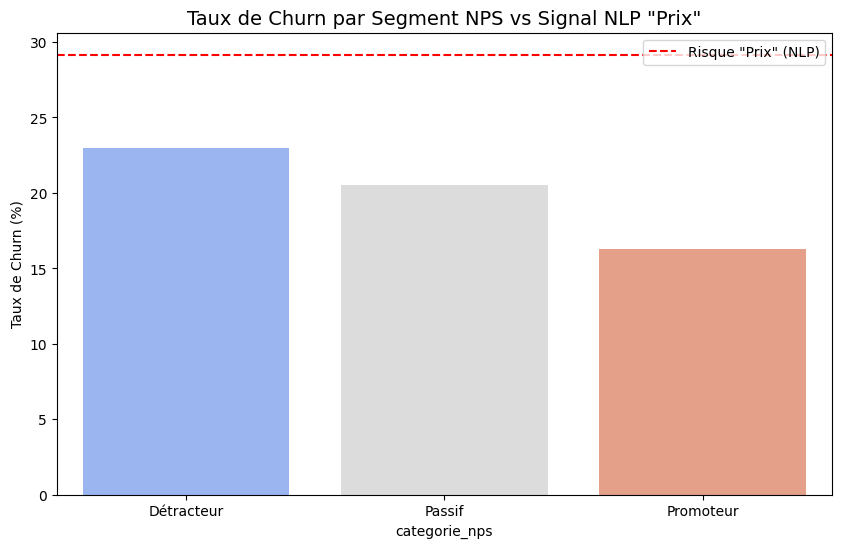

In [22]:
plt.figure(figsize=(10, 6))
sns.barplot(x=stats_nps.index, y=stats_nps.values, palette='coolwarm')
plt.axhline(taux_churn_prix, color='red', linestyle='--', label='Risque "Prix" (NLP)')
plt.title('Taux de Churn par Segment NPS vs Signal NLP "Prix"', fontsize=14)
plt.ylabel('Taux de Churn (%)')
plt.legend()
plt.show()

In [27]:
df_prix_negatif = df_nps[(df_nps['mention_prix'] == True) & (df_nps['sentiment_score_n'] < 0)]
# Calcul du taux de churn par catégorie NPS pour le segment prix négatif
resultat_churn_prix = df_prix_negatif.groupby('categorie_nps')['target_resiliation_6mois'].mean() * 100

# Affichage direct
print(resultat_churn_prix.sort_values(ascending=False))

categorie_nps
Détracteur    66.666667
Passif        16.666667
Promoteur      0.000000
Name: target_resiliation_6mois, dtype: float64


# 📊 Analyse – Impact du signal "Prix" sur la résiliation

---

## 🔍 Résultats globaux

- Nombre de clients mentionnant négativement le prix : **24**
- Taux de churn (segment "Prix") : **29.17%**
- Taux de churn global : **19.08%**

👉 **Les clients mentionnant le prix sont 1.5 fois plus susceptibles de résilier.**

---

## 🧠 Analyse par catégorie NPS (segment prix négatif)

| Catégorie NPS | Taux de churn |
|--------------|-------------|
| Détracteur   | 66.7%       |
| Passif       | 16.7%       |
| Promoteur    | 0.0%        |

---

## ⚠️ Interprétation

### 1. Effet amplificateur du prix

👉 Le signal "prix négatif" agit comme un **amplificateur de risque**

- Chez les **détracteurs**, le churn explose à **66.7%**
- Le prix devient un **facteur déclencheur de résiliation immédiate**

---

### 2. Rupture de la logique NPS classique

👉 Contrairement à l’analyse globale :

- Les **promoteurs ne churnent pas ici (0%)**
- Les **passifs restent modérés (16.7%)**

👉 Le prix ne touche pas tous les segments de la même manière

---

### 3. Interaction NPS × NLP

👉 Ce résultat montre une **interaction non linéaire** :

- Le prix est particulièrement dangereux **lorsqu’il est combiné à une insatisfaction forte**
- Le NPS seul ne capture pas cette dynamique

---

## 👻 Insight clé

> **Le prix n’est pas juste un facteur de risque — c’est un déclencheur de churn conditionnel.**

---

## 📈 Implications business

- Prioriser les **détracteurs mentionnant le prix** → segment critique
- Mettre en place des actions ciblées :
  - renégociation tarifaire
  - communication proactive
- Ne pas traiter tous les signaux "prix" de manière uniforme

---

## 🚀 Recommandations data

- Créer une variable :
  - `prix_negatif`
  - interaction : `prix_negatif × categorie_nps`
- Intégrer ces features dans les modèles de churn

---

## 🏁 Conclusion

- Le signal "prix" augmente fortement le risque de churn (**×1.5**)
- Son effet dépend fortement du profil client (NPS)
- L’analyse combinée **NPS + NLP est indispensable** pour détecter les clients à risque